pandas, matplotlib, seaborn을 통해 Titanic dataset을 활용한 시각화 실습을 진행한다.
- https://www.kaggle.com/datasets/yasserh/titanic-dataset

해당 실습은 다음 문서를 참고하여 진행한다.
- https://wikidocs.net/105104

In [ ]:
!pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pandas read_csv를 통해 csv file을 DataFrame으로 읽는다.
또한 .head()를 활용해 성공적으로 데이터를 DataFrame으로 읽었는지 확인한다.

In [4]:
titanic_df = pd.read_csv('./datasets/titanic.csv')
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


titanic_df DataFrame에서 데이터 및 Null값의 개수, Data type을 확인해본다. 

In [5]:
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


.value_counts()를 통해 특정 column에서 각 값의 발생 횟수를 확인할 수 있다.

따라서 여기서는 생존자, 사망자 수를 확인하기 위해, Survived column을 확인한다. 1=생존자, 0=사망자를 나타낸다.

In [8]:
titanic_df['Survived'].value_counts() 

Survived
0    549
1    342
Name: count, dtype: int64

matplotlib을 통해 bar, pie graph를 표현해보자.


<Axes: title={'center': 'Survived (pie)'}>

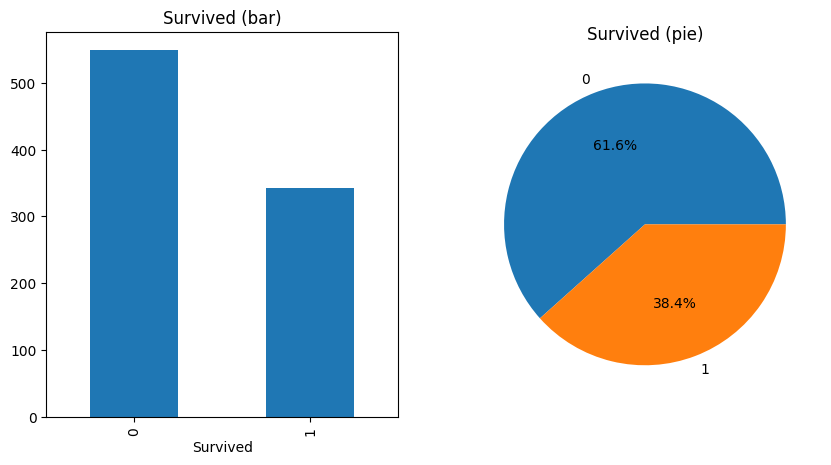

In [ ]:
plt.figure(figsize=(10, 5))  # 가로 10, 세로 5 inch의 공간 생성

plt.subplot(1, 2, 1)  # 공간을 1행 2열로 나누고, 첫 번째 열에 그래프를 생성한다.
plt.title('Survived (bar)')
titanic_df['Survived'].value_counts().plot(kind='bar')

plt.subplot(1, 2, 2)  # 공간 1행 2열 중 두 번째 열에 그래프를 생성한다.
plt.title('Survived (pie)')
titanic_df['Survived'].value_counts().plot(kind='pie', autopct='%.1f%%')  # %.1f%: 소수 첫째자리까지 표시, %.1f%%: % 기호 포함

<Axes: xlabel='Sex', ylabel='count'>

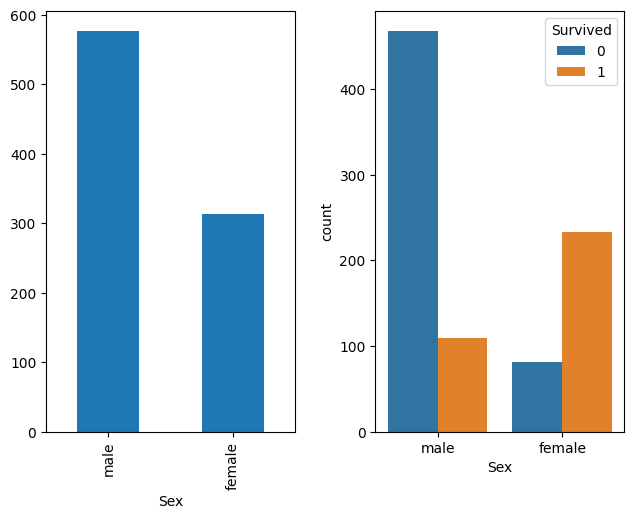

In [87]:
# 성별 분포에 대한 막대그래프
plt.subplot(1, 2, 1)
plt.tight_layout(w_pad=5)
titanic_df['Sex'].value_counts().plot(kind='bar')

# 성별에 따른 생존자, 사망자 분포
plt.subplot(1, 2, 2)
sns.countplot(data=titanic_df, x='Sex', hue='Survived')

.isnull()을 통해 결측치를 확인한다.

In [109]:
titanic_df.isnull() 
# null=True, notNull=False 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [110]:
titanic_df.isnull().sum()  # null=True, notNull=False
# True(=1), False(=0)이므로, sum을 통해 Null 수를 확인한다.

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [114]:
age_before = titanic_df[titanic_df['Age'].isnull()]  # 결측치 중 Age 값이 Null인 데이터 조회
age_before.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q


29.69911764705882


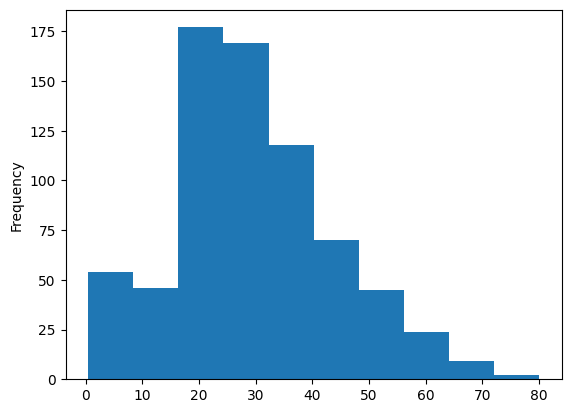

In [115]:
titanic_df['Age'].plot(kind='hist')  # 결측치 수정 이전의 나이 분포 히스토그램
mean_age = titanic_df['Age'].mean()  # 나이 평균값
print(mean_age)

결측치를 채우기 위해 .fillna()를 활용하여 평균 age 값으로 대체한다.

In [ ]:
titanic_df['Age'] = titanic_df['Age'].fillna(mean_age)
titanic_df[titanic_df.index.isin(age_before.index)]  # Null이었던 행들의 Age 값이 평균으로 변경되었는지 조회

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,29.699118,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,29.699118,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,29.699118,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,29.699118,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,29.699118,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,29.699118,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,29.699118,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,29.699118,0,0,349217,7.8958,NaN,S


<Axes: ylabel='Frequency'>

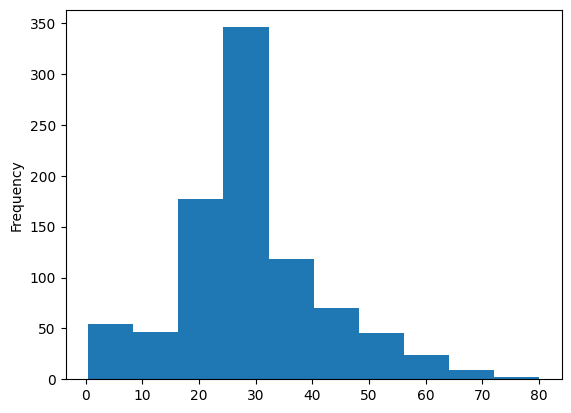

In [119]:
titanic_df['Age'].plot(kind='hist')  # 결측치 수정 후의 나이 분포 히스토그램